<a href="https://colab.research.google.com/github/amarman468/charity-management-system/blob/main/CIC_ToN_IoT_group_7__.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# =====================================================================
#  Member 1 (Steps 1 – 3)
#  Wahidul Islam Bayazid
#  ID:2023200000376
# =====================================================================
# =====================================================================
# STEP 1: ENVIRONMENT SETUP & DATA LOADING
# =====================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/Colab Notebooks/CIC-ToN-IoT.csv"

if not os.path.exists(file_path):
    raise FileNotFoundError(f"❌ Critical Error: File not found at: {file_path}")

print("📦 Loading dataset into memory... (This may take a minute)")
df = pd.read_csv(file_path, low_memory=False)
print("✅ Dataset Loaded Successfully!")
print(f"   → Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: ❌ Critical Error: File not found at: /content/drive/MyDrive/Colab Notebooks/CIC-ToN-IoT.csv

In [ ]:
# =====================================================================
# STEP 2: DATASET UNDERSTANDING
# =====================================================================
print("\n" + "="*60)
print("STEP 2: DATASET UNDERSTANDING")
print("="*60)

print(f"\n📊 Dataset Dimensions : {df.shape}")
print(f"\n🔍 Column Data Types  :\n{df.dtypes.value_counts()}")
print(f"\n🎯 Target Distribution:\n{df['Label'].value_counts()}")
print(f"\n❓ Missing Values     : {df.isnull().sum().sum()}")
print(f"🔁 Duplicate Rows     : {df.duplicated().sum():,}")
print(f"\n📋 Feature Preview:\n{df.head(3)}")



STEP 2: DATASET UNDERSTANDING

📊 Dataset Dimensions : (3000001, 84)

🔍 Column Data Types  :
float64    45
int64      35
object      4
Name: count, dtype: int64

🎯 Target Distribution:
Label
1    1590052
0    1409949
Name: count, dtype: int64

❓ Missing Values     : 0
🔁 Duplicate Rows     : 216,743

📋 Feature Preview:
                                  Flow ID         Src IP  Src Port  \
0        63.60.192.168-1.31.192.168-0-0-0  63.60.192.168         0   
1    192.168.1.35-192.168.1.1-58823-53-17   192.168.1.35     58823   
2  192.168.1.193-192.168.1.37-445-38439-6  192.168.1.193       445   

         Dst IP  Dst Port  Protocol               Timestamp  Flow Duration  \
0  1.31.192.168         0         0  24/04/2019 04:55:02 pm       12664600   
1   192.168.1.1        53        17  27/04/2019 06:48:05 pm           5505   
2  192.168.1.37     38439         6  28/04/2019 03:49:26 pm        3910132   

   Tot Fwd Pkts  Tot Bwd Pkts  ...  Fwd Seg Size Min  Active Mean  Active Std  \
0    

In [ ]:
# =====================================================================
# STEP 3: DATA HYGIENE & STRUCTURAL CLEANING
# =====================================================================
print("\n" + "="*60)
print("STEP 3: DATA CLEANING")
print("="*60)

# Strip whitespace from column headers
df.columns = df.columns.str.strip()

# Remove duplicate rows
duplicate_count = df.duplicated().sum()
print(f"🔁 Duplicate rows found : {duplicate_count:,}")
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("   → Duplicates removed.")

# Replace inf values with NaN then drop
df.replace([np.inf, -np.inf], np.nan, inplace=True)
pre_drop = df.shape[0]
df.dropna(inplace=True)
post_drop = df.shape[0]
print(f"♾️  Infinite/NaN rows removed: {pre_drop - post_drop:,}")
print(f"✅ Clean dataset shape  : {df.shape}")


STEP 3: DATA CLEANING
🔁 Duplicate rows found : 216,743
   → Duplicates removed.
♾️  Infinite/NaN rows removed: 644
✅ Clean dataset shape  : (2782614, 84)


In [ ]:
# =====================================================================
#  Member 2 (Steps 4 – 6)
#  Abdullah Mohammad Arman
#  ID:2023200000750
# =====================================================================


# =====================================================================
# STEP 4: DOWNSAMPLE & TARGET EXTRACTION
# =====================================================================
print("\n" + "="*60)
print("STEP 4: DOWNSAMPLING & TARGET EXTRACTION")
print("="*60)

TARGET_SAMPLE_SIZE = 300_000

if len(df) > TARGET_SAMPLE_SIZE:
    print(f"   Dataset too large ({len(df):,} rows). Downsampling to {TARGET_SAMPLE_SIZE:,}...")
    df = df.sample(n=TARGET_SAMPLE_SIZE, random_state=42).reset_index(drop=True)
    print(f"   → Downsampled shape: {df.shape}")

# Extract target vector
y = df['Label']
print(f"\n🎯 Target variable   : Label")
print(f"   Class distribution:\n{y.value_counts()}")


STEP 4: DOWNSAMPLING & TARGET EXTRACTION
   Dataset too large (2,782,614 rows). Downsampling to 300,000...
   → Downsampled shape: (300000, 84)

🎯 Target variable   : Label
   Class distribution:
Label
0    152062
1    147938
Name: count, dtype: int64


In [ ]:
# =====================================================================
# STEP 5: TRAIN / TEST SPLIT (before any transforms)
# =====================================================================
print("\n" + "="*60)
print("STEP 5: TRAIN / TEST SPLIT")
print("="*60)

from sklearn.model_selection import train_test_split

# Drop non-feature columns
columns_to_drop = ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Label']
existing_drops = [c for c in columns_to_drop if c in df.columns]
X = df.drop(columns=existing_drops)

# Stratified 70/30 split — done BEFORE any preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"✅ Training set  : {X_train.shape}")
print(f"✅ Testing set   : {X_test.shape}")


STEP 5: TRAIN / TEST SPLIT
✅ Training set  : (210000, 79)
✅ Testing set   : (90000, 79)


In [ ]:
# =====================================================================
# STEP 6: PREPROCESSING
# =====================================================================
print("\n" + "="*60)
print("STEP 6: PREPROCESSING")
print("="*60)

# Work on copies to avoid pandas SettingWithCopyWarning
X_train = X_train.copy()
X_test  = X_test.copy()

# --- 6a. Downcast numeric types to save RAM ---
for col in X_train.select_dtypes(include=['float64']).columns:
    X_train[col] = X_train[col].astype(np.float32)
    X_test[col]  = X_test[col].astype(np.float32)

for col in X_train.select_dtypes(include=['int64']).columns:
    X_train[col] = X_train[col].astype(np.int32)
    X_test[col]  = X_test[col].astype(np.int32)

# --- 6b. Encode categorical (object) columns ---
for col in X_train.select_dtypes(include=['object']).columns:
    train_factors, unique_classes = pd.factorize(X_train[col].astype(str))
    X_train[col] = train_factors.astype(np.int32)
    test_mapper  = {v: i for i, v in enumerate(unique_classes)}
    X_test[col]  = X_test[col].astype(str).map(test_mapper).fillna(-1).astype(np.int32)

print("✅ Type casting and categorical encoding done.")

# --- 6c. FIX: Remove zero-variance (constant) features BEFORE SelectKBest ---
# This eliminates the divide-by-zero warning during F-test scoring
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0)
X_train_vt = vt.fit_transform(X_train)
X_test_vt  = vt.transform(X_test)

kept_cols = X_train.columns[vt.get_support()].tolist()
removed   = X_train.shape[1] - len(kept_cols)
print(f"🧹 Constant (zero-variance) features removed : {removed}")
print(f"   → Remaining features after VarianceThreshold: {len(kept_cols)}")

X_train = pd.DataFrame(X_train_vt, columns=kept_cols)
X_test  = pd.DataFrame(X_test_vt,  columns=kept_cols)

# --- 6d. Univariate Feature Selection via SelectKBest ---
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected  = selector.transform(X_test)

chosen_features = X_train.columns[selector.get_support()].tolist()
print(f"\n✅ Top 10 features selected via SelectKBest:")
for i, f in enumerate(chosen_features, 1):
    print(f"   {i:2}. {f}")



STEP 6: PREPROCESSING
✅ Type casting and categorical encoding done.
🧹 Constant (zero-variance) features removed : 10
   → Remaining features after VarianceThreshold: 69

✅ Top 10 features selected via SelectKBest:
    1. Src Port
    2. Dst Port
    3. Protocol
    4. Fwd Pkt Len Max
    5. Fwd Pkt Len Mean
    6. Fwd Pkt Len Std
    7. Pkt Len Max
    8. Fwd Seg Size Avg
    9. Subflow Fwd Byts
   10. Init Fwd Win Byts



STEP 7: BALANCING DATASET WITH SMOTE
Applying SMOTE to balance training partition...


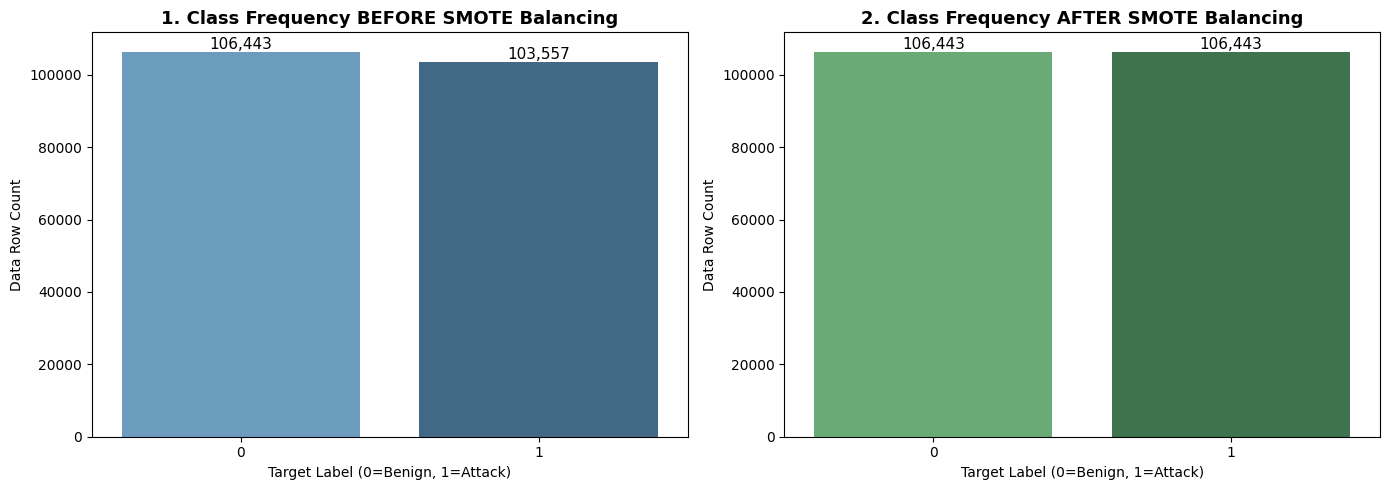

✅ Balanced training set size: 212,886 rows


In [ ]:
# =====================================================================
#  Member 1 (Steps 7 – 9)
#  Md. Nahid Parvez
#  ID:2023200000665
# =====================================================================


# =====================================================================
# STEP 7: MANDATORY — BALANCING DATASET (SMOTE)
# =====================================================================
print("\n" + "="*60)
print("STEP 7: BALANCING DATASET WITH SMOTE")
print("="*60)

from imblearn.over_sampling import SMOTE

# Plot BEFORE balancing
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x=y_train, ax=axes[0], hue=y_train, palette='Blues_d', legend=False)
axes[0].set_title('1. Class Frequency BEFORE SMOTE Balancing', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Target Label (0=Benign, 1=Attack)')
axes[0].set_ylabel('Data Row Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Apply SMOTE — training data ONLY
print("Applying SMOTE to balance training partition...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_selected, y_train)

# Plot AFTER balancing
sns.countplot(x=y_train_resampled, ax=axes[1], hue=y_train_resampled, palette='Greens_d', legend=False)
axes[1].set_title('2. Class Frequency AFTER SMOTE Balancing', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Target Label (0=Benign, 1=Attack)')
axes[1].set_ylabel('Data Row Count')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('class_balance_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Balanced training set size: {len(y_train_resampled):,} rows")


In [ ]:
# =====================================================================
# STEP 8: SCALING (fit on resampled train, transform test)
# =====================================================================
print("\n" + "="*60)
print("STEP 8: FEATURE SCALING")
print("="*60)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

# Fit scaler ONLY on resampled training data — no leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled  = scaler.transform(X_test_selected)

print("✅ StandardScaler applied (fit on train, transform-only on test).")

# Performance tracking dictionary
global_performance_logs = {}

# Universal evaluation helper
def evaluate_model(model_name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)

    global_performance_logs[model_name] = [acc, prec, rec, f1]

    print(f"\n📈 ===== {model_name} Evaluation Summary =====")
    print(f"   Accuracy  : {acc:.4f}")
    print(f"   Precision : {prec:.4f}")
    print(f"   Recall    : {rec:.4f}")
    print(f"   F1-Score  : {f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Benign', 'Attack'],
                yticklabels=['Benign', 'Attack'])
    plt.title(f'{model_name} — Confusion Matrix', fontsize=13, fontweight='bold')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_")}_confusion_matrix.png', dpi=150)
    plt.show()



STEP 8: FEATURE SCALING
✅ StandardScaler applied (fit on train, transform-only on test).



STEP 9: MACHINE LEARNING MODELS

[1/3] Training Decision Tree Classifier...

📈 ===== Decision Tree Evaluation Summary =====
   Accuracy  : 0.9847
   Precision : 0.9847
   Recall    : 0.9847
   F1-Score  : 0.9847


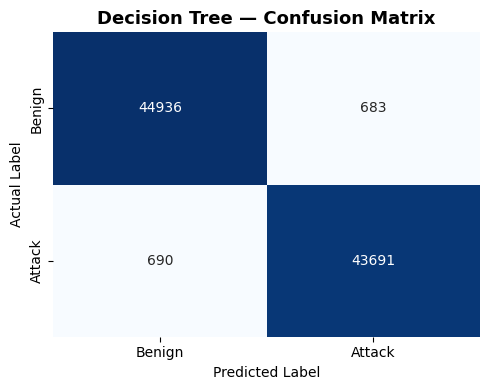


[2/3] Training Random Forest Classifier...

📈 ===== Random Forest Evaluation Summary =====
   Accuracy  : 0.9880
   Precision : 0.9880
   Recall    : 0.9881
   F1-Score  : 0.9880


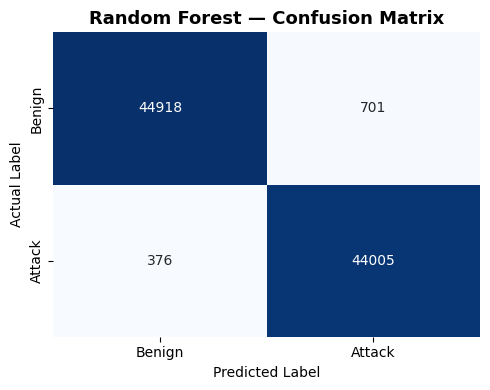


[3/3] Training XGBoost Classifier...

📈 ===== XGBoost Evaluation Summary =====
   Accuracy  : 0.9919
   Precision : 0.9919
   Recall    : 0.9920
   F1-Score  : 0.9919


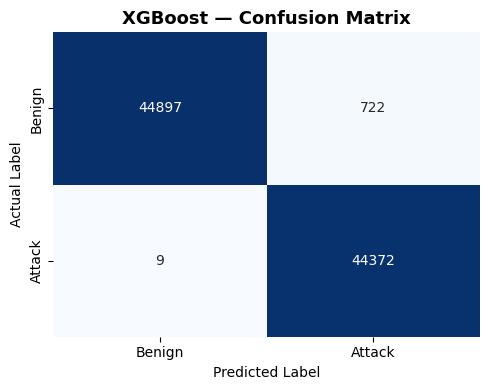

In [ ]:
# =====================================================================
# STEP 9: MACHINE LEARNING MODELS
# =====================================================================
print("\n" + "="*60)
print("STEP 9: MACHINE LEARNING MODELS")
print("="*60)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# --- Model 1: Decision Tree ---
print("\n[1/3] Training Decision Tree Classifier...")
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train_resampled)
evaluate_model("Decision Tree", y_test, dt.predict(X_test_scaled))

# --- Model 2: Random Forest ---
print("\n[2/3] Training Random Forest Classifier...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train_resampled)
evaluate_model("Random Forest", y_test, rf.predict(X_test_scaled))

# --- Model 3: XGBoost ---
print("\n[3/3] Training XGBoost Classifier...")
import xgboost as xgb
xgb_clf = xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
xgb_clf.fit(X_train_scaled, y_train_resampled)
evaluate_model("XGBoost", y_test, xgb_clf.predict(X_test_scaled))



STEP 10: BASE NEURAL NETWORK
Building base neural network architecture...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 64 (256.00 B)


Training Base Neural Network...
Epoch 1/20
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9741 - loss: 0.0967 - val_accuracy: 0.9897 - val_loss: 0.0511
Epoch 2/20
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9868 - loss: 0.0614 - val_accuracy: 0.9904 - val_loss: 0.0482
Epoch 3/20
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9877 - loss: 0.0576 - val_accuracy: 0.9903 - val_loss: 0.0471
Epoch 4/20
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9880 - loss: 0.0556 - val_accuracy: 0.9894 - val_loss: 0.0484
Epoch 5/20
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9883 - loss: 0.0540 - val_accuracy: 0.9906 - val_loss: 0.0461
Epoch 6/20
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9883 - loss: 0.0534 - val_accuracy: 0.9907 - val_loss: 0.0461
Epoch 7/20
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9884 - loss: 0.0529 - val_accuracy: 0.9907 - val_loss: 0.0460
Epoch 8/20
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step -

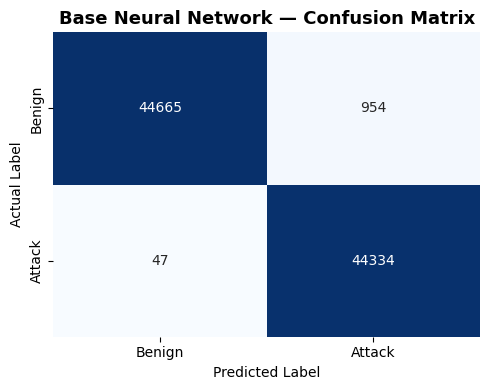

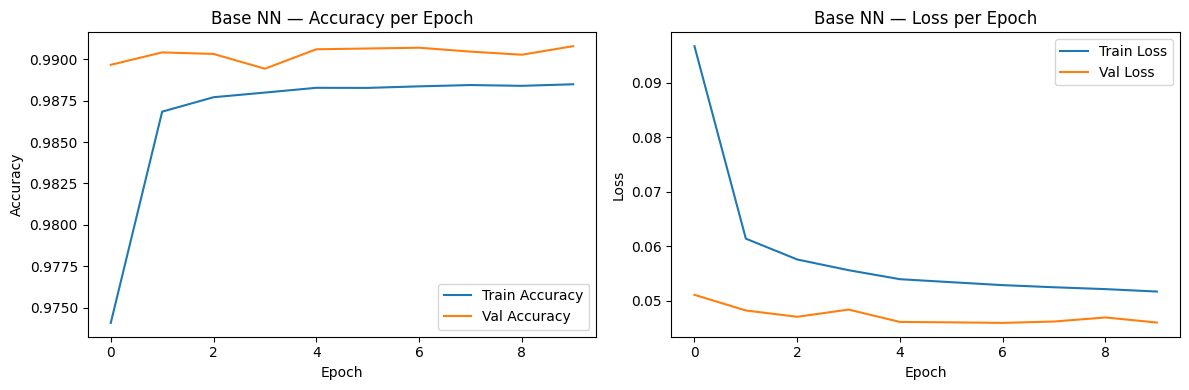

In [ ]:
# =====================================================================
#  Member 1 (Steps 10 – 12)
#  Abir Ahmed
#  ID:2023200000666
# =====================================================================

# =====================================================================
# STEP 10: NEURAL NETWORK — BASE MODEL
# =====================================================================
print("\n" + "="*60)
print("STEP 10: BASE NEURAL NETWORK")
print("="*60)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

print("Building base neural network architecture...")

base_nn = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

base_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
base_nn.summary()

# Fresh EarlyStopping callback for base model
es_base = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\nTraining Base Neural Network...")
history_base = base_nn.fit(
    X_train_scaled, y_train_resampled,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    callbacks=[es_base],
    verbose=1
)

nn_base_preds = (base_nn.predict(X_test_scaled) > 0.5).astype("int32").flatten()
evaluate_model("Base Neural Network", y_test, nn_base_preds)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_base.history['accuracy'], label='Train Accuracy')
plt.plot(history_base.history['val_accuracy'], label='Val Accuracy')
plt.title('Base NN — Accuracy per Epoch')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_base.history['loss'], label='Train Loss')
plt.plot(history_base.history['val_loss'], label='Val Loss')
plt.title('Base NN — Loss per Epoch')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.savefig('base_nn_training_history.png', dpi=150)
plt.show()



STEP 11: TUNED NEURAL NETWORK (IMPROVEMENT)
Building tuned neural network (wider layers, adjusted LR)...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 192 (768.00 B)


Training Tuned Neural Network...
Epoch 1/30
2994/2994 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9730 - loss: 0.0990 - val_accuracy: 0.9868 - val_loss: 0.0553
Epoch 2/30
2994/2994 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9854 - loss: 0.0635 - val_accuracy: 0.9893 - val_loss: 0.0488
Epoch 3/30
2994/2994 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.9872 - loss: 0.0579 - val_accuracy: 0.9904 - val_loss: 0.0467
Epoch 4/30
2994/2994 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9880 - loss: 0.0548 - val_accuracy: 0.9904 - val_loss: 0.0460
Epoch 5/30
2994/2994 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9882 - loss: 0.0534 - val_accuracy: 0.9902 - val_loss: 0.0463
Epoch 6/30
2994/2994 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9883 - loss: 0.0530 - val_accuracy: 0.9906 - val_loss: 0.0457
Epoch 7/30
2994/2994 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9886 - loss: 0.0524 - val_accuracy: 0.9904 - val_loss: 0.0457
Epoch 8/30
2994/2994 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms

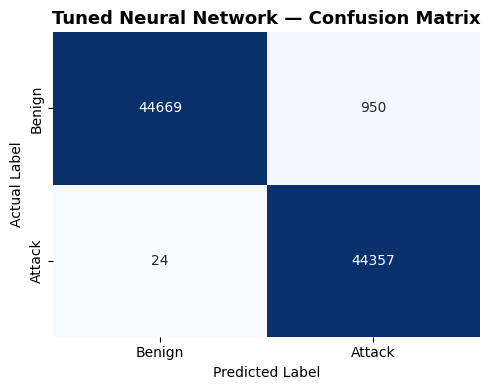

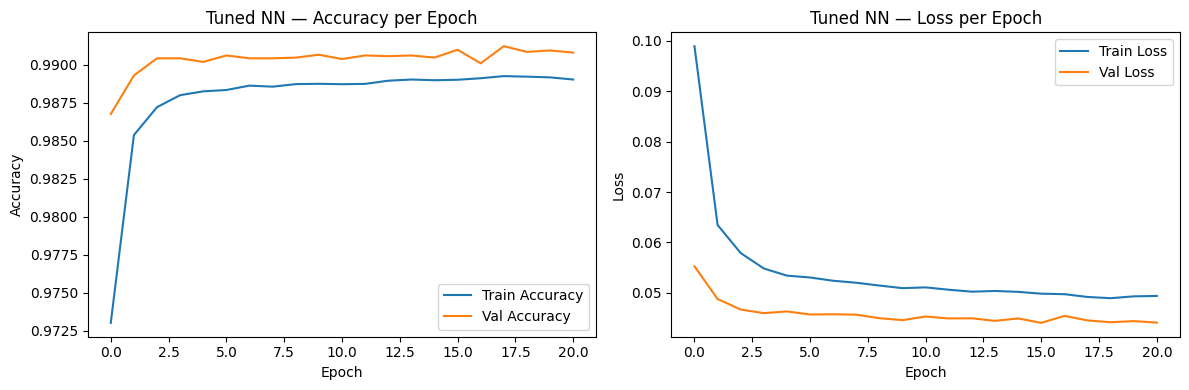

In [ ]:
# =====================================================================
# STEP 11: NEURAL NETWORK — TUNED MODEL (IMPROVEMENT)
# =====================================================================
print("\n" + "="*60)
print("STEP 11: TUNED NEURAL NETWORK (IMPROVEMENT)")
print("="*60)

from tensorflow.keras.optimizers import Adam

print("Building tuned neural network (wider layers, adjusted LR)...")

tuned_nn = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')
])

tuned_nn.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
tuned_nn.summary()

# FIX: Fresh EarlyStopping for the tuned model — higher patience
# so the lower LR has enough epochs to converge properly
es_tuned = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\nTraining Tuned Neural Network...")
history_tuned = tuned_nn.fit(
    X_train_scaled, y_train_resampled,
    epochs=30,          # More epochs for lower LR to converge
    batch_size=64,
    validation_split=0.1,
    callbacks=[es_tuned],
    verbose=1
)

tuned_preds = (tuned_nn.predict(X_test_scaled) > 0.5).astype("int32").flatten()
evaluate_model("Tuned Neural Network", y_test, tuned_preds)

# Plot tuned model training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_tuned.history['accuracy'], label='Train Accuracy')
plt.plot(history_tuned.history['val_accuracy'], label='Val Accuracy')
plt.title('Tuned NN — Accuracy per Epoch')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_tuned.history['loss'], label='Train Loss')
plt.plot(history_tuned.history['val_loss'], label='Val Loss')
plt.title('Tuned NN — Loss per Epoch')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.savefig('tuned_nn_training_history.png', dpi=150)
plt.show()


        ✨  FINAL EXPERIMENTAL PERFORMANCE SUMMARY REPORT  ✨
| Model                      | Accuracy | Precision |   Recall | F1-Score |
|----------------------------|----------|-----------|----------|----------|
| Decision Tree              |   98.47% |    98.47% |   98.47% |   98.47% |
| Random Forest              |   98.80% |    98.80% |   98.81% |   98.80% |
| XGBoost                    |   99.19% |    99.19% |   99.20% |   99.19% |
| Base Neural Network        |   98.89% |    98.89% |   98.90% |   98.89% |
| Tuned Neural Network       |   98.92% |    98.92% |   98.93% |   98.92% |

🏆 Best Performing Model : XGBoost  (F1 = 99.19%)


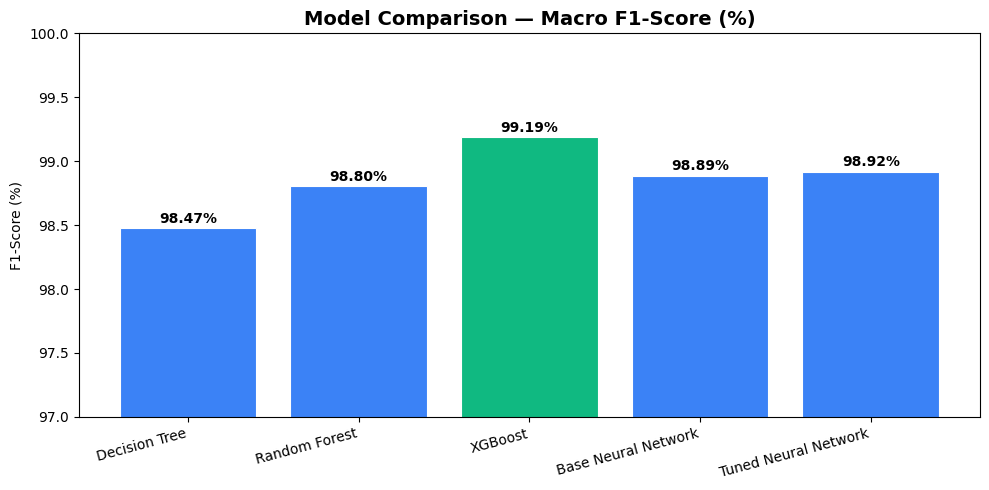


✅ Pipeline complete. All models trained, evaluated, and compared.


In [ ]:
# =====================================================================
# STEP 12: FINAL PERFORMANCE COMPARISON REPORT
# =====================================================================
print("\n" + "="*70)
print("        ✨  FINAL EXPERIMENTAL PERFORMANCE SUMMARY REPORT  ✨")
print("="*70)
print(f"| {'Model':<26} | {'Accuracy':>8} | {'Precision':>9} | {'Recall':>8} | {'F1-Score':>8} |")
print("|" + "-"*28 + "|" + "-"*10 + "|" + "-"*11 + "|" + "-"*10 + "|" + "-"*10 + "|")

for model_name, metrics in global_performance_logs.items():
    acc, prec, rec, f1 = metrics
    print(f"| {model_name:<26} | {acc*100:>7.2f}% | {prec*100:>8.2f}% | {rec*100:>7.2f}% | {f1*100:>7.2f}% |")

print("="*70)

# Find best model
best_model = max(global_performance_logs, key=lambda k: global_performance_logs[k][3])
best_f1    = global_performance_logs[best_model][3]
print(f"\n🏆 Best Performing Model : {best_model}  (F1 = {best_f1*100:.2f}%)")

# Bar chart comparison of all models
models  = list(global_performance_logs.keys())
f1s     = [global_performance_logs[m][3] * 100 for m in models]
colors  = ['#3B82F6' if m != best_model else '#10B981' for m in models]

plt.figure(figsize=(10, 5))
bars = plt.bar(models, f1s, color=colors, edgecolor='white', linewidth=0.8)
plt.ylim(97, 100)
plt.title('Model Comparison — Macro F1-Score (%)', fontsize=14, fontweight='bold')
plt.ylabel('F1-Score (%)')
plt.xticks(rotation=15, ha='right')

for bar, val in zip(bars, f1s):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Pipeline complete. All models trained, evaluated, and compared.")
